In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import topovelo as tpv
import matplotlib.pyplot as plt

In [2]:
DATA_NAME = 'curio-seq-embryoid'
DATA_DIR = ''
adata = sc.read(f"{DATA_DIR}/{DATA_NAME}-out.h5ad")

# 1. Velocity Stream and Cell Developmental Time

In [5]:
color_map = {
    'Early Ectoderm': '#000000',
    'Endoderm': '#DF526B',
    'Endothelial': '#62D14F',
    'Mesoderm': '#2297E6',
    'Neural Crest': '#28E2E5',
    'Neurons': '#CD2FBC',
    'Pluripotent': '#F5C70E',
}
palette = list(color_map.values())
stream_plot_config = {
    'width': 3,
    'real_aspect_ratio': True,
    'markersize': 30,
    'density': 0.8,
    'palette': palette
}
time_plot_config = {
    'width': 6,
    'markersize': 10,
    'linewidths': 0.0,
    'show_colorbar': True
}

Overwriting the original KNN graph! (.uns, .obsp)


---   Plotting  Results   ---
Computing a spatial graph using KNN on spatial with k=50
computing neighbors
    finished (0:00:03) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing velocity graph (using 2/32 cores)


  0%|          | 0/5559 [00:00<?, ?cells/s]

    finished (0:00:25) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_spatial', embedded velocity vectors (adata.obsm)


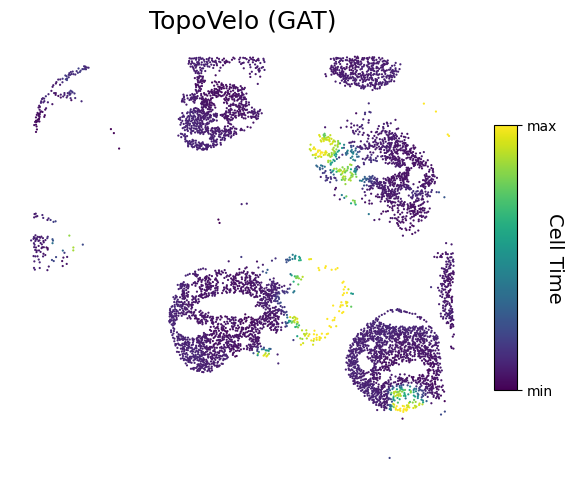

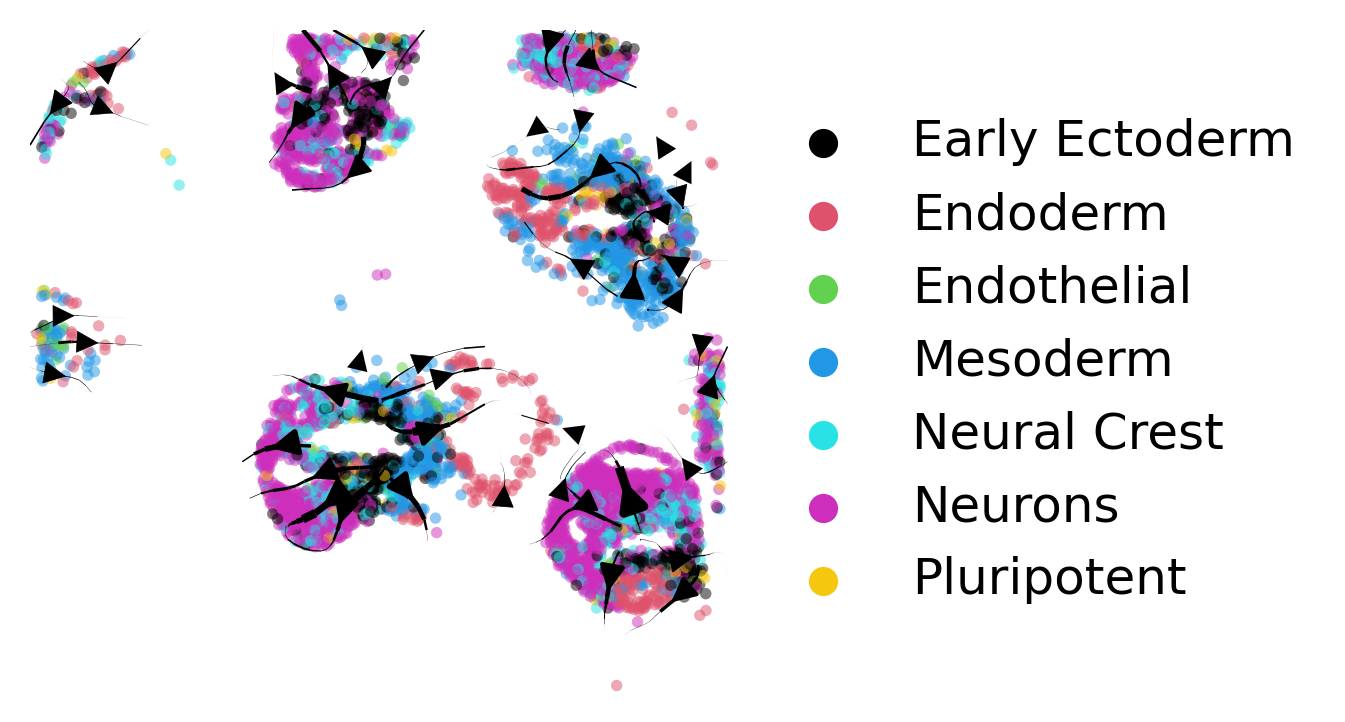

Recovering the original KNN graph from .uns


In [4]:
_ = tpv.post_analysis(
    adata,
    DATA_NAME,
    ['TopoVelo (GAT)'],
    ['gat'],
    cluster_key='rctd_clusters',
    plot_type=['time', 'cell velocity'],
    stream_plot_config=stream_plot_config,
    time_plot_config=time_plot_config,
    dpi=300
)

# Velocity on UMAP

---   Plotting  Results   ---
computing velocity graph (using 2/32 cores)


  0%|          | 0/5559 [00:00<?, ?cells/s]

    finished (0:00:43) --> added 
    'gat_velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'gat_velocity_umap', embedded velocity vectors (adata.obsm)


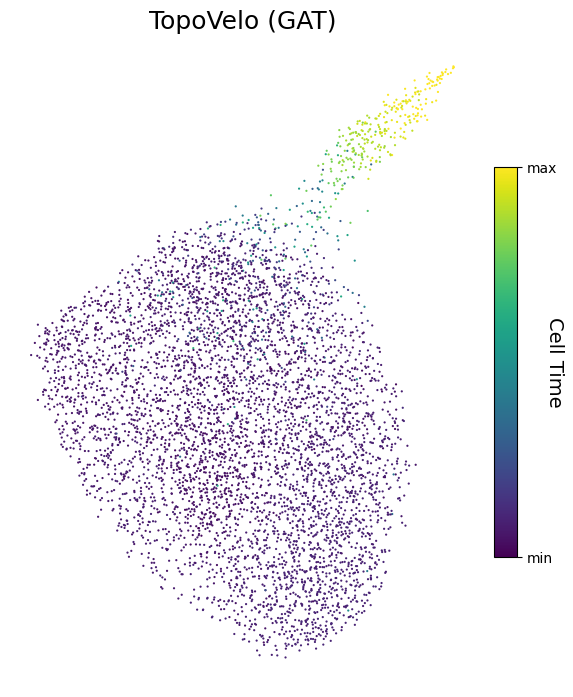

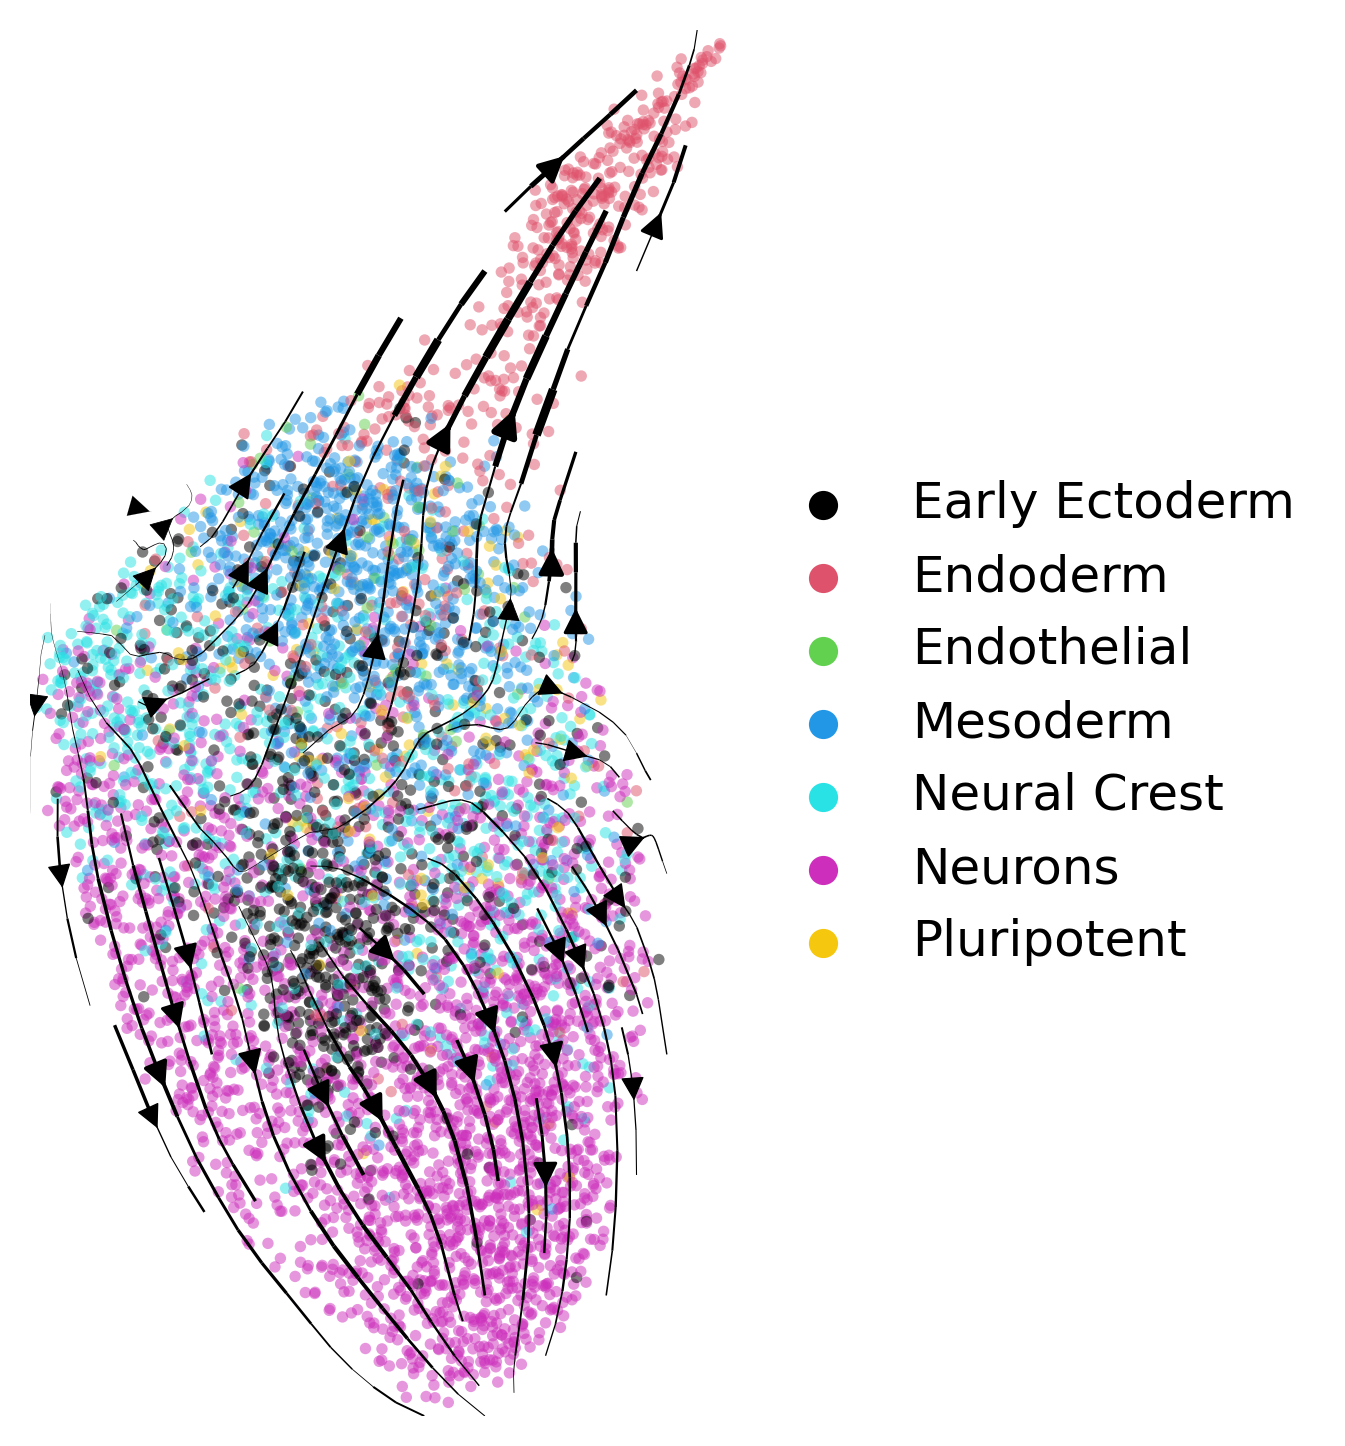

In [7]:
_ = tpv.post_analysis(
    adata,
    DATA_NAME,
    ['TopoVelo (GAT)'],
    ['gat'],
    cluster_key='rctd_clusters',
    plot_basis='umap',
    plot_type=['time', 'embed velocity'],
    stream_plot_config=stream_plot_config,
    time_plot_config=time_plot_config,
    dpi=300
)

# Attention score

In [8]:
import torch
import torch_geometric.transforms as gt

In [9]:
CKPT_DIR = ''

In [11]:
vae = tpv.VAE(adata, 
              tmax=20, 
              dim_z=5, 
              spatial_graph_key='spatial_graph',
              device='cuda:0',
              graph_decoder=True,
              attention=True,
              full_vb=True,
              checkpoints=[f'{CKPT_DIR}/encoder.pt', f'{CKPT_DIR}/decoder.pt'])

In [12]:
data = np.concatenate([adata.layers['Mu'], adata.layers['Ms']], 1)
data = torch.tensor(data).float().to(vae.device)
att_enc = vae.get_enc_att_all_pairs(data, adata.n_obs, batch_size=128)

In [16]:
data = torch.tensor(adata.obsm['gat_z']).float().to(vae.device)
att_dec = vae.get_dec_att_all_pairs(data, adata.n_obs, batch_size=128)

In [13]:
att_src = att_enc.mean(2).sum(1)


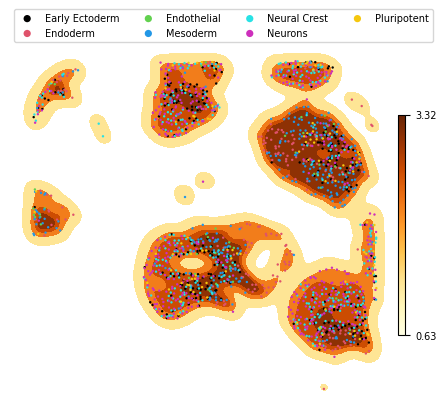

In [15]:
cell_labels = adata.obs['rctd_clusters'].to_numpy()
tpv.plotting.plot_heat_density(att_src,
                               adata.obsm['X_spatial'],
                               width=5,
                               height=6,
                               radius=50,
                               cell_labels=cell_labels,
                               n_grid=100,
                               levels=5,
                               ncols=4,
                               bbox_to_anchor=[0.15, 1, 0.8, 0.1],
                               legend_fontsize=7,
                               cmap='YlOrBr',
                               markersize=3,
                               markerscale=3,
                               palette=palette,
                               colorbar_name='',
                               colorbar_pos=[1.0, 0.2, 0.02, 0.6],
                               colorbar_tick_fontsize=7,
                               colorbar_labelpad=0,
                               colorbar_fontsize=12,
                               sample_per_bin=1,
                               bw_adjust=0.3)

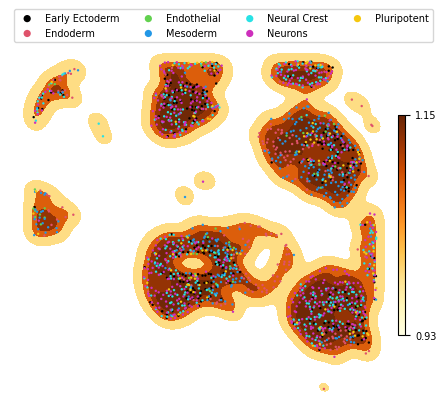

In [17]:
att_src_dec = att_dec.mean(2).sum(1)
cell_labels = adata.obs['rctd_clusters'].to_numpy()
tpv.plotting.plot_heat_density(att_src_dec,
                               adata.obsm['X_spatial'],
                               width=5,
                               height=6,
                               radius=50,
                               cell_labels=cell_labels,
                               n_grid=100,
                               levels=5,
                               ncols=4,
                               bbox_to_anchor=[0.15, 1, 0.8, 0.1],
                               legend_fontsize=7,
                               cmap='YlOrBr',
                               markersize=3,
                               markerscale=3,
                               palette=palette,
                               colorbar_name='',
                               colorbar_pos=[1.0, 0.2, 0.02, 0.6],
                               colorbar_tick_fontsize=7,
                               colorbar_labelpad=0,
                               colorbar_fontsize=12,
                               sample_per_bin=1,
                               bw_adjust=0.3)

In [18]:
df_ci = pd.DataFrame(att_src, index=adata.obs_names, columns=['Cell Influcence Score'])
df_ci.to_csv(f'{DATA_DIR}/cell_influcence.csv')

In [19]:
#df_ci = pd.read_csv(f'{data_path_base}/cell_influcence.csv')
score = df_ci['Cell Influcence Score'].values
thred = np.quantile(score, 0.9)
adata.obs['Cell Influence Score'] = score * (score >= thred)

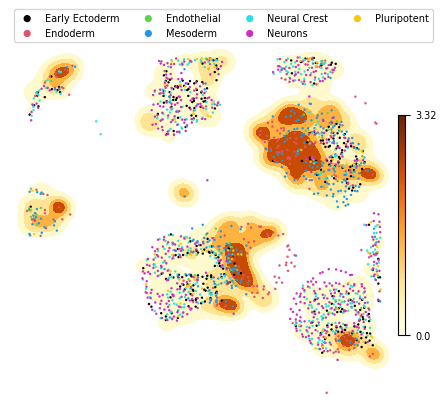

In [21]:
cell_labels = adata.obs['rctd_clusters'].to_numpy()
tpv.plotting.plot_heat_density(score * (score >= thred),
                               adata.obsm['X_spatial'],
                               width=5,
                               height=6,
                               radius=50,
                               cell_labels=cell_labels,
                               n_grid=200,
                               levels=5,
                               ncols=4,
                               bbox_to_anchor=[0.15, 1, 0.8, 0.1],
                               legend_fontsize=7,
                               cmap='YlOrBr',
                               markersize=3,
                               markerscale=3,
                               palette=palette,
                               colorbar_name='',
                               colorbar_pos=[1.0, 0.2, 0.02, 0.6],
                               colorbar_tick_fontsize=7,
                               colorbar_labelpad=0,
                               colorbar_fontsize=12,
                               sample_per_bin=1,
                               bw_adjust=0.3)